Business problem: Allocate marketing resources more efficiently by targeting customers based on purchasing power.
Retail businesses care about:
Conversion rate
Average order value

Lifetime value (LTV)
Because positive rate = 6%, this is imbalanced.

Business implication:

High-income group is small.

Precision matters.

False positives waste premium marketing spend.

So evaluation should focus on:

Precision at top K

PR-AUC

Lift charts

Not accuracy.

ROI of campaigns
ML problem: 

Identify high-spending potential customers and treat them differently from low-spending potential customers.

5️⃣ What Makes It Valuable

If the model works:

Instead of blasting campaigns to everyone:

They can target top 20% predicted earners

Increase response rate

Increase average basket size

Reduce wasted advertising spend

Even a small lift in precision can generate large financial gains at scale.

Income prediction is a means, not the end.

The end is:

Marketing segmentation

Resource optimization

Revenue lift

reading column names file
reading the comma-separated data
cleaning ? / whitespace / trailing periods
basic EDA (missingness, target split, numeric summaries, top categories, quick feature associations)
a baseline classifier (logistic regression) with a clean preprocessing pipeline
a segmentation model (k-means on encoded features) + how segments differ

In [1]:
# 1. load & clean

import pandas as pd
import numpy as np

from pathlib import Path

DATA_PATH = Path("census-bureau.data")
COLS_PATH = Path("census-bureau.columns")

def load_columns(cols_path: Path) -> list[str]:
    # .columns looks like one name per line
    cols = pd.read_csv(cols_path, header=None, names=["col"])["col"].tolist()
    cols = [c.strip() for c in cols if str(c).strip() != ""]
    return cols

def load_data(data_path: Path, cols: list[str]) -> pd.DataFrame:
    # Data is comma-separated; lots of spaces after commas
    df = pd.read_csv(
        data_path,
        header=None,
        names=cols,
        sep=",",
        engine="python",
        skipinitialspace=True
    )

    # Standardize strings
    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        df[c] = (
            df[c].astype(str)
                 .str.strip()
                 .replace({"?": np.nan, "nan": np.nan})
        )

    # Many targets are like "- 50000." or "50000+."
    # Strip trailing periods from all object columns
    for c in obj_cols:
        df[c] = df[c].str.replace(r"\.$", "", regex=True)

    return df

cols = load_columns(COLS_PATH)
df = load_data(DATA_PATH, cols)

print("shape:", df.shape)
df.head()


shape: (199523, 42)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000


In [2]:
# 2. identify target with premise checks:
target_col = df.columns[-1]
print("target_col:", target_col)
print(df[target_col].value_counts(dropna=False))

def to_binary_target(x: str) -> int:
    # adapt if your label text differs
    # examples: "- 50000" vs "50000+"
    if pd.isna(x):
        return np.nan
    x = str(x)
    if "50000+" in x or ">50K" in x or "over" in x.lower():
        return 1
    if "- 50000" in x or "<=50K" in x or "less" in x.lower():
        return 0
    # fallback: try numeric-ish
    return 1 if "+" in x else 0

df["y"] = df[target_col].apply(to_binary_target).astype("Int64")
print(df["y"].value_counts(dropna=False))


target_col: label
label
- 50000    187141
50000+      12382
Name: count, dtype: int64
y
0       187141
1        12382
<NA>         0
Name: count, dtype: Int64


In [3]:
# Missingness
missing = df.isna().mean().sort_values(ascending=False)
print("Top missing columns:\n", missing.head(15))

# Split columns
feature_cols = [c for c in df.columns if c not in [target_col, "y"]]
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("num:", len(num_cols), "cat:", len(cat_cols))

# Target rate
y_rate = df["y"].mean()
print("Positive rate (income > 50k):", float(y_rate))




Top missing columns:
 migration code-change in msa                  0.499672
migration code-change in reg                  0.499672
migration code-move within reg                0.499672
migration prev res in sunbelt                 0.499672
country of birth father                       0.033645
country of birth mother                       0.030668
country of birth self                         0.017006
hispanic origin                               0.004380
state of previous residence                   0.003548
citizenship                                   0.000000
own business or self employed                 0.000000
detailed household and family stat            0.000000
fill inc questionnaire for veteran's admin    0.000000
family members under 18                       0.000000
num persons worked for employer               0.000000
dtype: float64
num: 13 cat: 28
Positive rate (income > 50k): 0.06205800834991455


In [11]:
migration_cols = [
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt"
]

for c in migration_cols:
    print(c)
    print(pd.crosstab(df[c].isna(), df["y"], normalize="index"))


migration code-change in msa
y                                    0         1
migration code-change in msa                    
False                         0.941509  0.058491
True                          0.934370  0.065630
migration code-change in reg
y                                    0         1
migration code-change in reg                    
False                         0.941509  0.058491
True                          0.934370  0.065630
migration code-move within reg
y                                      0         1
migration code-move within reg                    
False                           0.941509  0.058491
True                            0.934370  0.065630
migration prev res in sunbelt
y                                     0         1
migration prev res in sunbelt                    
False                          0.941509  0.058491
True                           0.934370  0.065630


class imbalance is significant. 
Migration related data have near 50% missing values. They are unlikely to drive income strongly and will introduce noise.
-migration code-change in msa
-migration code-change in reg
-migration code-move within reg
-migration prev res in sunbelt
Therefore I will drop these.

Baseline positive rate ≈ 6.21%
based on the output:
Missing group → 5.85%
Non-missing group → 6.56%
Difference ≈ 0.7% absolute
Relative lift ≈ 12%
This is small.
Given:
50% missing
Likely correlated with other geography variables
Adds dimensional complexity
Drop all four migration variables.
They do not provide strong standalone separation.

for other missing data:
Categorical → fill with "Missing"
Numeric → median

In [4]:
TOP_K = 10
for c in cat_cols[:10]:  # first 10, adjust as needed
    vc = df[c].value_counts(dropna=False).head(TOP_K)
    print(f"\n{c} (top {TOP_K})")
    print(vc)



class of worker (top 10)
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64

education (top 10)
education
High school graduate                      48407
Children                                  47422
Some college but no degree                27820
Bachelors degree(BA AB BS)                19865
7th and 8th grade                          8007
10th grade                                 7557
11th grade                                 6876
Masters degree(MA MS MEng MEd MSW MBA)     6541
9th grade                                  6230
Associates degree-occup /vocational        5358
Name: count, dtype: int64

enroll in edu inst last wk

2️⃣ Investigate “Not in universe” categories
Many categorical variables have:
* "Not in universe"
* "Children"
* Similar administrative categories
These often correspond to:
* minors
* unemployed
* not applicable
You should:
* Keep them for now
* Later test whether they act as strong signals
Do not drop yet.


In [ ]:
# find variables actually separate income groups:

# education vs income 
pd.crosstab(df["education"], df["y"], normalize="index").sort_values(1, ascending=False).head(15)



y,0,1
education,,
Prof school degree (MD DDS DVM LLB JD),0.459565,0.540435
Doctorate degree(PhD EdD),0.479810,0.520190
Masters degree(MA MS MEng MEd MSW MBA),0.688427,0.311573
Bachelors degree(BA AB BS),0.802920,0.197080
Associates degree-academic program,0.905570,0.094430
Associates degree-occup /vocational,0.922919,0.077081
Some college but no degree,0.935766,0.064234
High school graduate,0.961183,0.038817
12th grade no diploma,0.984008,0.015992


In [6]:
# occupation vs. income 
pd.crosstab(df["major occupation code"], df["y"], normalize="index").sort_values(1, ascending=False).head(15)



y,0,1
major occupation code,,
Executive admin and managerial,0.712445,0.287555
Professional specialty,0.750717,0.249283
Armed Forces,0.777778,0.222222
Protective services,0.844070,0.155930
Sales,0.870661,0.129339
Technicians and related support,0.880384,0.119616
Precision production craft & repair,0.909203,0.090797
Transportation and material moving,0.935572,0.064428
Farming forestry and fishing,0.949142,0.050858


      count       mean        std   min   25%   50%   75%   max
y                                                              
0  187141.0  33.715316  22.620236   0.0  14.0  31.0  49.0  90.0
1   12382.0  46.266193  11.830906  16.0  38.0  45.0  53.0  90.0


<Axes: title={'center': 'age'}, xlabel='y'>

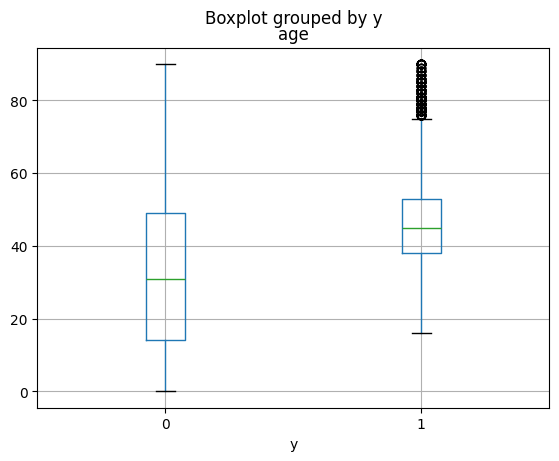

In [9]:
# age distribution
print(df.groupby("y")["age"].describe())
df.boxplot(column="age", by="y")



In [ ]:
# distribution of year
df["year"].value_counts()

correlation analysis 
2️⃣ Strong Signals Identified
Now look at what really separates income.
Education
Massive gradient:
* Prof degree → 54%
* PhD → 52%
* Masters → 31%
* Bachelor → 19%
* High school → 3.8%
* Below HS → <1%
This is extremely strong signal.
👉 Keep education. 👉 Consider ordinal encoding (education has natural order).

Major Occupation
Very strong separation:
* Executive → 28.8%
* Professional → 24.9%
* Clerical → 3%
* Service → 1%
Also strong signal.
👉 Keep major occupation code. 👉 Drop detailed occupation for now (high cardinality).

Age
Mean age:
* Low income: 33.7
* High income: 46.3
Very strong separation.
👉 Keep age. 👉 Consider non-linear relationship (tree model handles naturally).

In [ ]:
### 
remove leakage - since we're investigating real demographic marketing, we're going to remove high leakge data
eg:
wage per hour
capital gains
capital losses
dividends

Model A: No financial variables
Model B: With financial variables
###



In [18]:
drop_cols = [
    "year",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "detailed industry recode",
    "detailed occupation recode",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt",
    "weight"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


1. year
* Survey year (1994 or 1995)
Why drop:
* It does not describe the individual.
* It reflects macroeconomic timing.
* It will not exist for future prospects in marketing.
* It risks learning year-specific income distribution rather than person-level signal.
If you include it, the model may partially learn:
“People surveyed in 1995 earned slightly more”
That is not a meaningful marketing feature.

2. Financial Variables 
wage per hour
capital gains
capital losses
dividends from stocks
These are problematic because they are either:
* Direct income components
* Strong income proxies
Your target is:
Income > 50K
If you include wage, capital gains, or dividends, the model is effectively seeing income.
This creates target leakage.
Leakage means: The model learns something that would not be available at prediction time.
From a retail perspective:
Would your client realistically know:
* Capital gains?
* Dividends?
* Hourly wage?
Almost certainly not.
So keeping them gives artificially high accuracy but no real-world usability.

3. Detailed Occupation / Industry Recode 

detailed industry recode
detailed occupation recode
Problems:
* Very high cardinality
* Many rare categories
* Increases dimensionality significantly
* Causes unstable one-hot encoding
You already have:

major industry code
major occupation code
These are aggregated versions with strong signal.
Start with major codes.We can revisit detailed codes later if performance is insufficient.

4. Migration Variables
Missing group → 5.85% Non-missing group → 6.56%
Difference ≈ 0.7%
That is weak.
Additionally:
* 50% missing
* Adds complexity
* Hard to interpret in marketing context
For retail segmentation, migration is unlikely to be a primary income driver.
So cost > benefit.

5. survey weight
Survey weight is used to:
* Estimate population-level proportions
It is not an individual characteristic.
Including it:
* Does not help prediction
* May introduce bias
Unless you are building weighted models for population inference, drop it.


In [19]:
feature_cols = [c for c in df.columns if c not in [target_col, "y"]]
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print(feature_cols)
print(num_cols)
print(cat_cols)


['age', 'class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked in year']
['age', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year']
['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic 

In [20]:
for col in num_cols:
    print("\n", col)
    print(df.groupby("y")[col].mean())



 age
y
0    33.715316
1    46.266193
Name: age, dtype: float64

 num persons worked for employer
y
0    1.820707
1    4.003715
Name: num persons worked for employer, dtype: float64

 own business or self employed
y
0    0.169674
1    0.262559
Name: own business or self employed, dtype: float64

 veterans benefits
y
0    1.483967
1    1.981344
Name: veterans benefits, dtype: float64

 weeks worked in year
y
0    21.527762
1    48.069617
Name: weeks worked in year, dtype: float64


In [23]:
pd.crosstab(df[col], df["y"], normalize="index").sort_values(1, ascending=False)


y,0,1
weeks worked in year,,
52,0.851992,0.148008
51,0.890110,0.109890
50,0.892795,0.107205
49,0.893910,0.106090
46,0.911017,0.088983
48,0.913068,0.086932
41,0.920455,0.079545
37,0.934959,0.065041
29,0.936508,0.063492


52 weeks → 14.8%
50 weeks → 10.7%
45 weeks → 5.7%
30 weeks → 3.0%
0 weeks → 0.6%
shows nonlinear pattern, so logistic regression with a linear term may underfit this pattern.

In [ ]:
# consider binning for linear regression while keep the origional value for tree models since they learn these patterns automatically 
def bin_weeks(x):
    if x == 0:
        return "0"
    elif x < 26:
        return "1-25"
    elif x < 48:
        return "26-47"
    else:
        return "48-52"


In [ ]:
# This computes each categorical column’s max lift over baseline, plus coverage and number of levels. It’s a fast way to prioritize.

import numpy as np
import pandas as pd

baseline = df["y"].mean()

def cat_signal_summary(df, cat_cols, y_col="y", min_count=200):
    rows = []
    for c in cat_cols:
        s = df[c].astype("object").fillna("Missing")
        tmp = pd.DataFrame({"x": s, "y": df[y_col]})
        vc = tmp["x"].value_counts(dropna=False)
        # only evaluate levels with enough support
        keep_levels = vc[vc >= min_count].index
        grp = tmp[tmp["x"].isin(keep_levels)].groupby("x")["y"].agg(["mean", "count"])
        if grp.empty:
            continue

        max_rate = grp["mean"].max()
        min_rate = grp["mean"].min()
        max_lift = max_rate / baseline if baseline > 0 else np.nan
        min_lift = min_rate / baseline if baseline > 0 else np.nan

        rows.append({
            "feature": c,
            "n_levels": int(tmp["x"].nunique()),
            "missing_rate": float(df[c].isna().mean()),
            "coverage_ge_min": float(grp["count"].sum() / len(df)),
            "max_rate": float(max_rate),
            "min_rate": float(min_rate),
            "max_lift_over_baseline": float(max_lift),
            "min_lift_over_baseline": float(min_lift),
        })

    out = pd.DataFrame(rows).sort_values("max_lift_over_baseline", ascending=False)
    return out

cat_summary = cat_signal_summary(df, cat_cols, y_col="y", min_count=200)
cat_summary.head(20)


,feature,n_levels,missing_rate,coverage_ge_min,max_rate,min_rate,max_lift_over_baseline,min_lift_over_baseline
1,education,17,0.000000,1.000000,0.540435,0.000000,8.708546,0.000000
0,class of worker,9,0.000000,0.999173,0.347320,0.004556,5.596700,0.073412
5,major occupation code,15,0.000000,0.999820,0.287555,0.002564,4.633649,0.041318
4,major industry code,24,0.000000,0.998882,0.259325,0.005291,4.178752,0.085259
21,country of birth self,43,0.017006,0.991244,0.174020,0.008721,2.804144,0.140529
15,detailed household and family stat,38,0.000000,0.996632,0.147423,0.000000,2.375574,0.000000
20,country of birth mother,43,0.030668,0.993715,0.139415,0.006757,2.246524,0.108878
19,country of birth father,43,0.033645,0.992507,0.136207,0.004494,2.194832,0.072422
9,member of a labor union,3,0.000000,1.000000,0.135974,0.056234,2.191073,0.906158
23,fill inc questionnaire for veteran's admin,3,0.000000,1.000000,0.134965,0.040921,2.174828,0.659395


In [25]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder

def chi2_rank(df, cat_cols, y_col="y", min_count=100):
    X = df[cat_cols].copy()
    for c in cat_cols:
        X[c] = X[c].astype("object").fillna("Missing")

        # collapse rare levels to reduce noise before chi2
        vc = X[c].value_counts()
        rare = vc[vc < min_count].index
        X.loc[X[c].isin(rare), c] = "Other"

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    X_ohe = ohe.fit_transform(X)
    y = df[y_col].astype(int).values

    chi2_vals, pvals = chi2(X_ohe, y)

    # aggregate chi2 back to original feature using encoder feature names
    feat_names = ohe.get_feature_names_out(cat_cols)
    chi_df = pd.DataFrame({"ohe_feat": feat_names, "chi2": chi2_vals, "pval": pvals})
    chi_df["orig_feat"] = chi_df["ohe_feat"].str.split("_", n=1).str[0]
    agg = chi_df.groupby("orig_feat")["chi2"].sum().sort_values(ascending=False)
    return agg.reset_index().rename(columns={"orig_feat":"feature", "chi2":"chi2_sum"})

chi_rank = chi2_rank(df, cat_cols, y_col="y", min_count=100)
chi_rank.head(20)


,feature,chi2_sum
0,education,30322.049718
1,major occupation code,26765.882894
2,major industry code,15404.367654
3,class of worker,13542.953109
4,detailed household and family stat,11529.389364
5,tax filer stat,10484.359945
6,detailed household summary in household,10301.203726
7,marital stat,7794.867355
8,full or part time employment stat,5098.018910
9,family members under 18,5054.768316


data leakage variables - cateogorical: 
tax filer stat → too income-adjacent
fill inc questionnaire for veteran's admin → administrative artifact

1️⃣ Tier 1 — Must Keep (Very Strong Signal)
These are extremely powerful predictors:
Feature	Max Lift
education	8.7x
class of worker	5.6x
major occupation code	4.6x
major industry code	4.2x
These are core economic variables.
✅ Keep all four.
These alone likely get you strong PR-AUC.

2️⃣ Tier 2 — Strong But Consider Carefully
Feature	Max Lift
country of birth self	2.8x
detailed household and family stat	2.37x
country of birth mother	2.25x
country of birth father	2.19x
member of labor union	2.19x
fill inc questionnaire for veteran's admin	2.17x
full or part time employment stat	2.12x
tax filer stat	2.11x
Now we apply business reasoning.
🚫 Drop Immediately (Leakage / Administrative)
* tax filer stat → too income-adjacent
* fill inc questionnaire for veteran's admin → administrative artifact
These inflate performance but hurt deployability.

⚠️ Country of birth variables
Strong lift, but:
* 43 levels
* Potential fairness / compliance issues
* Hard to justify in retail targeting
If this is a school assignment → optional If this is real business → likely exclude

Full or part time employment stat
This is useful and aligned with income logic.
But you already have:
* weeks worked (very strong)
Check redundancy:
If correlation high, choose one.
Often:
* Keep weeks worked
* Drop full/part

Labor union
Moderate lift. Low cardinality. Reasonable business justification.
Optional keep.

3️⃣ Tier 3 — Moderate
Feature	Max Lift
marital stat	1.84x
sex	1.64x
citizenship	1.59x
family members under 18	1.38x
Marital status is usually strong in income models.
Sex and citizenship may raise fairness considerations.
Family members under 18 → weaker but usable.

4️⃣ Tier 4 — Weak
Feature	Max Lift
state of previous residence	1.28x
race	1.19x
hispanic origin	1.10x
These are weak relative to others.
Unless performance gain is measurable, drop them.

Recommended Final Categorical Set (Balanced + Deployable)
Keep
* education
* class of worker
* major occupation code
* major industry code
* marital stat
* weeks_bin (your engineered variable)
Optional (if needed for lift):
* member of labor union

Recommended Drop
* tax filer stat
* fill inc questionnaire for veteran's admin
* country of birth *
* detailed household *
* state of previous residence
* hispanic origin
* race (optional — depends on fairness policy)
* citizenship (optional)
